<a href="https://colab.research.google.com/github/Sariga98/cloud-based-ecommerce-pipeline-aws/blob/main/cloud_based_ecommerce_pipeline_aws.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

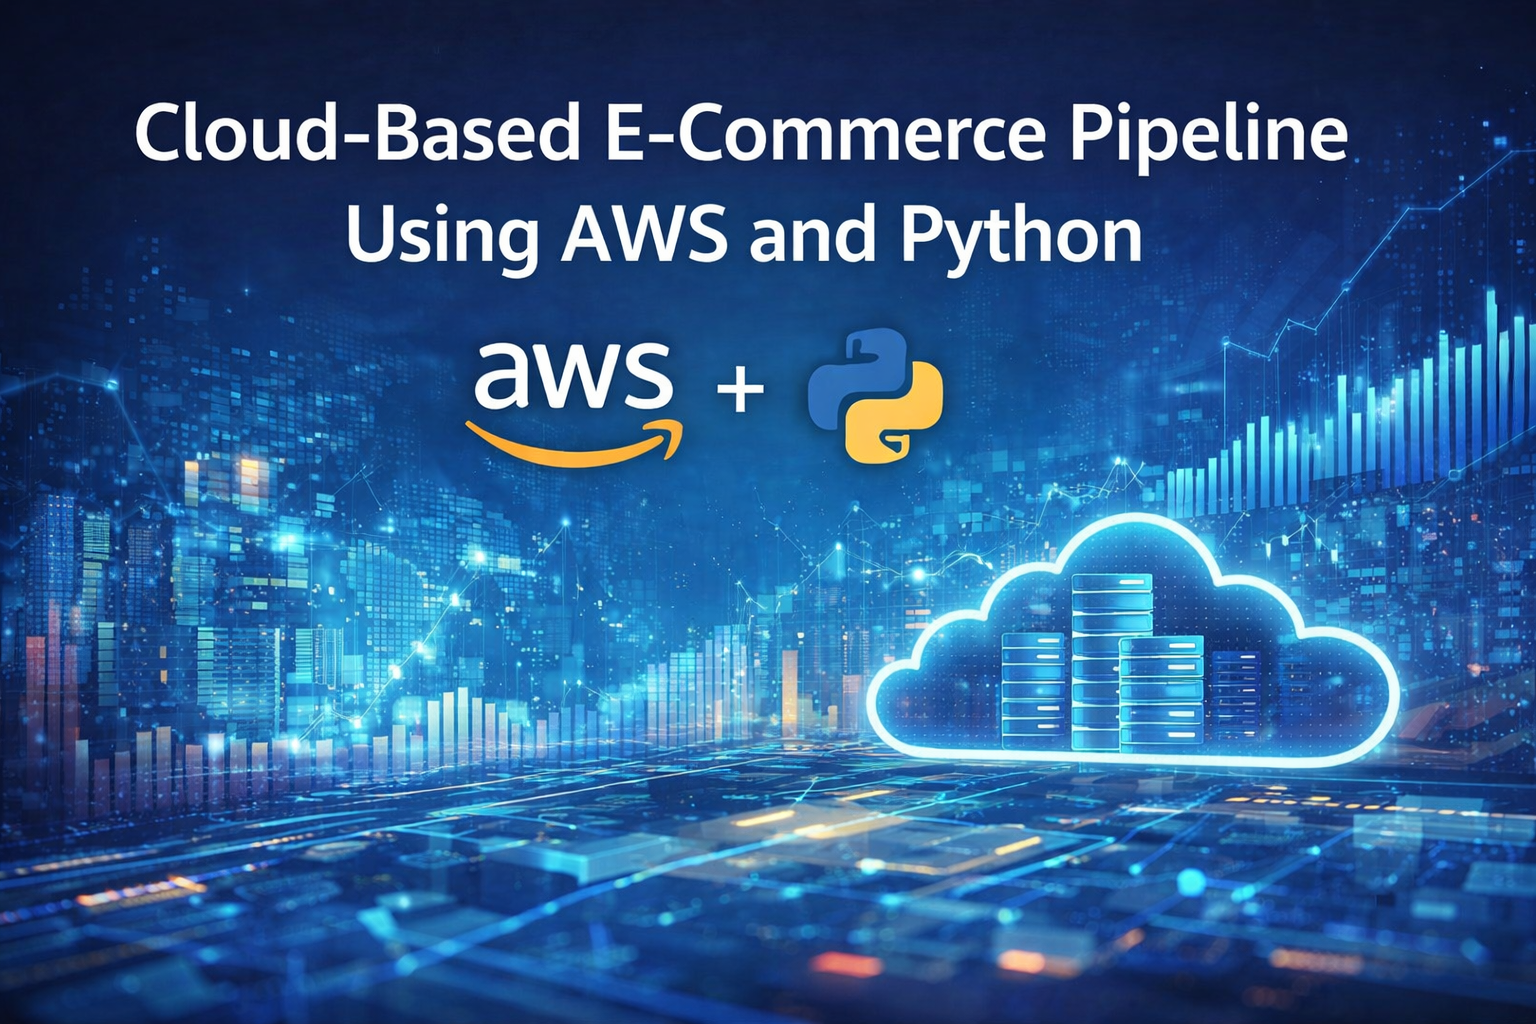

## **1. Install Required Libraries**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn prophet nltk boto3 pyarrow fastparquet statsmodels


## **1.1 Import Core Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import boto3
import os
from datetime import datetime

# NLP
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Forecasting
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## **1.2 Environment Sanity Check**

In [ ]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("boto3:", boto3.__version__)


Pandas: 2.2.2
NumPy: 2.0.2
boto3: 1.42.17


### **2. AWS IAM & S3 SETUP**



1.   Create S3 Bucket (One-Time, AWS Console)
2.   Create IAM User

#### **2.1 CONFIGURE AWS ACCESS IN GOOGLE COLAB**

In [ ]:
import getpass

AWS_ACCESS_KEY_ID = getpass.getpass("Enter AWS Access Key ID: ")
AWS_SECRET_ACCESS_KEY = getpass.getpass("Enter AWS Secret Access Key:")
AWS_REGION = "us-east-1"
S3_BUCKET = "ecommerce-analytics-olist-grp5"


Enter AWS Access Key ID: ··········
Enter AWS Secret Access Key:··········


#### **2.3 Create S3 Client & Validate Access**

In [ ]:
import boto3

s3 = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_REGION
)

# Test connection
[b['Name'] for b in s3.list_buckets()['Buckets']]


['ecommerce-analytics-grp5-2025', 'ecommerce-analytics-olist-grp5']

## **3. DATA INGESTION LAYER**

In [ ]:
import os
import zipfile
from google.colab import files

zip_path = "/content/Brazilian Olist.zip"
extract_path = "/content/olist_data"

# Step 1: Upload ZIP if not present
if not os.path.exists(zip_path):
    print("ZIP not found. Please upload the dataset.")
    files.upload()

# Step 2: Extract only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")


ZIP not found. Please upload the dataset.


Saving Brazilian Olist.zip to Brazilian Olist.zip
Dataset extracted successfully.


#### **3.1 Load All Tables (Schema Validation)**

In [ ]:
import pandas as pd

data_path = "/content/olist_data"

tables = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv"
}

dfs = {name: pd.read_csv(f"{data_path}/{file}") for name, file in tables.items()}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")


customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


#### **3.2 Data Cleaning & Standardization**
*  Convert Date Columns (Critical)






In [ ]:
orders = dfs["orders"].copy()

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


## **4. DATA LAKE (AWS S3 – RAW ZONE)**

*   Upload Raw Data to S3








In [ ]:
raw_prefix = "data-lake/raw/"

for name, df in dfs.items():
    local_path = f"/content/{name}.csv"
    s3_path = f"{raw_prefix}{name}.csv"

    df.to_csv(local_path, index=False)
    s3.upload_file(local_path, S3_BUCKET, s3_path)

print("Raw zone successfully created in S3.")


Raw zone successfully created in S3.


## **5. ETL PROCESS & DATA MODELING**

* A Python-based ETL layer was implemented to replicate AWS Glue functionality. The ETL process performs data cleaning, normalization, integration, and feature engineering before loading curated datasets into the processed zone of the data lake.



#### 5.1 Aggregate Order Items

In [ ]:
order_items = dfs["order_items"]
payments = dfs["order_payments"]

order_value = (
    order_items
    .groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_freight=("freight_value", "sum"),
        total_price=("price", "sum")
    )
    .reset_index()
)

order_value.head()


,order_id,total_items,total_freight,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,1,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,1,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,1,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,18.14,199.90


#### 5.2 Aggregate Payments

In [ ]:
payment_value = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

payment_value.head()


,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


#### **5.3 Create Fact Table**

In [ ]:
fact_orders = (
    orders
    .merge(order_value, on="order_id", how="left")
    .merge(payment_value, on="order_id", how="left")
)

fact_orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_freight,total_price,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,8.72,29.99,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,22.76,118.70,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,19.22,159.90,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,27.20,45.00,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,8.72,19.90,28.62,1.0


#### **5.4 Create Dimension table for Customers,Products and Time**

In [ ]:
customers = dfs["customers"]

dim_customers = customers[[
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state"
]].drop_duplicates()

dim_customers.head()


,customer_id,customer_unique_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


In [ ]:
products = dfs["products"]
categories = dfs["category_translation"]

dim_products = (
    products
    .merge(categories, on="product_category_name", how="left")
)

dim_products = dim_products[[
    "product_id",
    "product_category_name_english",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]]

dim_products.head()


,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,625.0,20.0,17.0,13.0


In [ ]:
dim_time = (
    fact_orders[["order_purchase_timestamp"]]
    .dropna()
    .drop_duplicates()
)

dim_time["date"] = dim_time["order_purchase_timestamp"].dt.date
dim_time["year"] = dim_time["order_purchase_timestamp"].dt.year
dim_time["month"] = dim_time["order_purchase_timestamp"].dt.month
dim_time["day"] = dim_time["order_purchase_timestamp"].dt.day
dim_time["weekday"] = dim_time["order_purchase_timestamp"].dt.weekday

dim_time.head()


,order_purchase_timestamp,date,year,month,day,weekday
0,2017-10-02 10:56:33,2017-10-02,2017,10,2,0
1,2018-07-24 20:41:37,2018-07-24,2018,7,24,1
2,2018-08-08 08:38:49,2018-08-08,2018,8,8,2
3,2017-11-18 19:28:06,2017-11-18,2017,11,18,5
4,2018-02-13 21:18:39,2018-02-13,2018,2,13,1


#### **5.5 LOAD PROCESSED DATA → AWS S3**

In [ ]:
processed_prefix = "data-lake/processed/"

tables_processed = {
    "fact_orders": fact_orders,
    "dim_customers": dim_customers,
    "dim_products": dim_products,
    "dim_time": dim_time
}

for name, df in tables_processed.items():
    local_path = f"/content/{name}.parquet"
    s3_path = f"{processed_prefix}{name}.parquet"

    df.to_parquet(local_path, index=False)
    s3.upload_file(local_path, S3_BUCKET, s3_path)

print("Processed data successfully uploaded to S3.")


Processed data successfully uploaded to S3.


## **6. ANALYTICS & MACHINE LEARNING**



1.   Descriptive analytics (KPIs)
2.   Sentiment analysis (NLP)
3. Sales forecasting (Prophet vs ARIMA)
4. Evaluation metrics (MAE, RMSE)

#### **6.1 DESCRIPTIVE ANALYTICS (SALES KPIs)**




##### **6.1.1 Basic Sales Metrics**

In [ ]:
# Remove cancelled orders for clean analytics
sales_df = fact_orders[
    fact_orders["order_status"] == "delivered"
].copy()

total_revenue = sales_df["total_price"].sum()
total_orders = sales_df["order_id"].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: {avg_order_value:,.2f}")


Total Revenue: 13,221,498.11
Total Orders: 96,478
Average Order Value: 137.04


These metrics support:

1.   Business performance evaluation
2.   Executive-level reporting
3.   Dashboard KPIs (QuickSight-ready)

##### **6.1.2 Monthly Sales Trend**

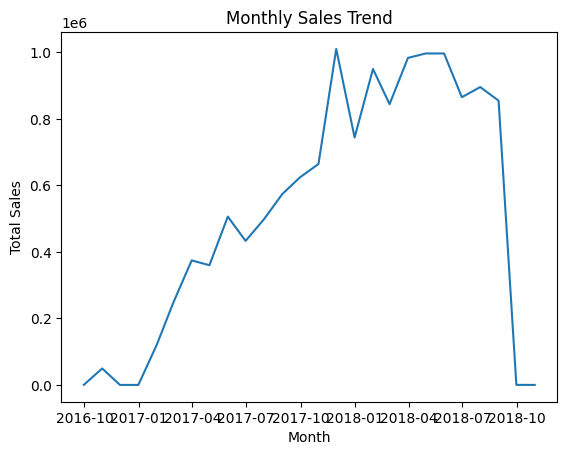

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = (
    fact_orders
    .set_index("order_purchase_timestamp")
    .resample("ME")["total_price"]
    .sum()
    .reset_index()
)

plt.figure()
plt.plot(monthly_sales["order_purchase_timestamp"],
         monthly_sales["total_price"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

This directly supports:
1.   Time-series analysis
2.   Seasonal trend detection

#### **6.2 SENTIMENT ANALYSIS (CUSTOMER REVIEWS)**

##### **6.2.1 Prepare Review Data**

In [ ]:
reviews = dfs["order_reviews"].copy()

reviews = reviews[[
    "order_id",
    "review_score",
    "review_comment_message"
]]

reviews = reviews.dropna(subset=["review_comment_message"])

reviews.head()
print(f"Reviews with comments: {len(reviews)}")


Reviews with comments: 40977


#### **6.2.2 Apply VADER Sentiment Analysis**


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

reviews["sentiment"] = reviews["review_comment_message"].apply(get_sentiment)

reviews["sentiment"].value_counts()


,count
sentiment,
neutral,33304
negative,4597
positive,3076


This satisfies:
1.   NLP-based sentiment classification
2.   Customer satisfaction analysis

#### **6.2.3 Sentiment vs Sales Correlation**



In [ ]:
sentiment_sales = (
    reviews
    .merge(sales_df[["order_id", "total_price"]], on="order_id", how="left")
)

sentiment_sales.groupby("sentiment")["total_price"].mean()


,total_price
sentiment,
negative,145.183305
neutral,145.455438
positive,153.353753


#### **6.3 SALES FORECASTING**

##### **6.3.1 Prepare Time-Series Data**

In [ ]:
ts_data = monthly_sales.rename(
    columns={
        "order_purchase_timestamp": "ds",
        "total_price": "y"
    }
)

ts_data.head()


,ds,y
0,2016-09-30,267.36
1,2016-10-31,49507.66
2,2016-11-30,0.00
3,2016-12-31,10.90
4,2017-01-31,120312.87


#### **6.3.2 Prophet Model**

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.


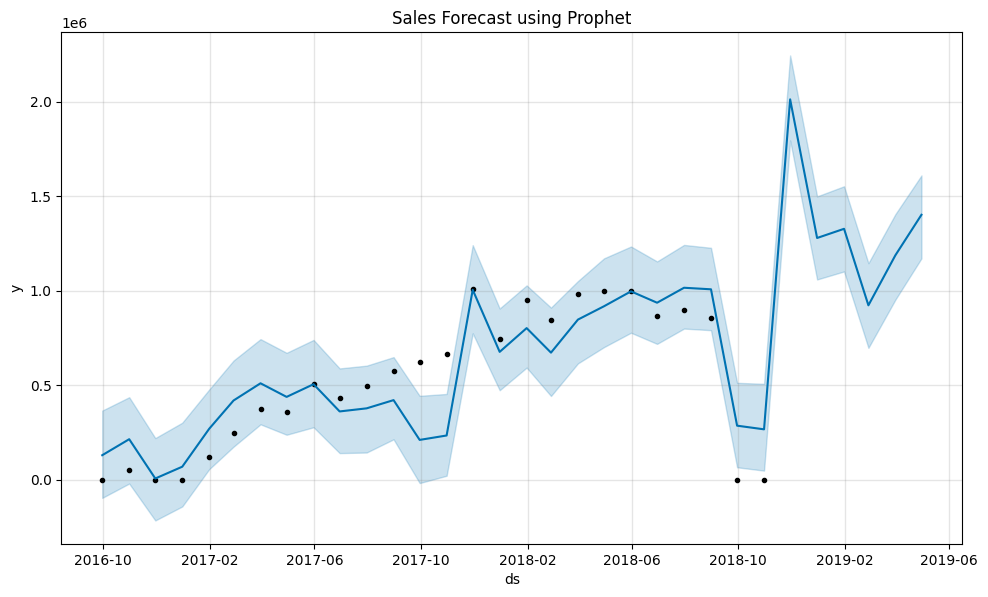

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

prophet_model = Prophet()
prophet_model.fit(ts_data)

future = prophet_model.make_future_dataframe(periods=6, freq="ME")
forecast = prophet_model.predict(future)

prophet_model.plot(forecast)
plt.title("Sales Forecast using Prophet")
plt.show()

#### **6.3.3 ARIMA Model**

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -249.466
Date:                Fri, 26 Dec 2025   AIC                            504.933
Time:                        23:54:01   BIC                            507.766
Sample:                             0   HQIC                           505.412
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7857      0.621     -1.265      0.206      -2.004       0.432
ma.L1          0.4489      0.700      0.641      0.521      -0.923       1.821
sigma2      1.826e+10   5.84e-11   3.13e+20      0.0

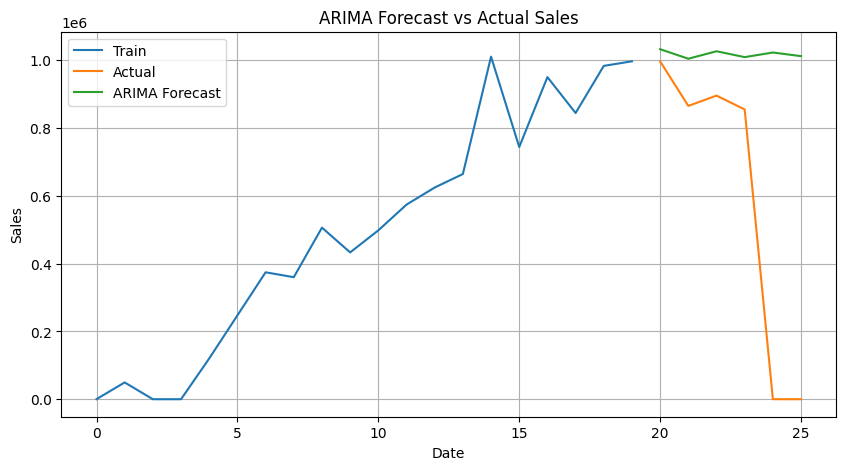

In [ ]:
# -----------------------------
# ARIMA MODEL: TRAIN, FORECAST, EVALUATE
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train-test split
train_size = int(len(ts_data) * 0.8)
train = ts_data.iloc[:train_size]
test = ts_data.iloc[train_size:]

# Fit ARIMA model
arima_model = ARIMA(train["y"], order=(1, 1, 1))
arima_result = arima_model.fit()

# Display model summary
print(arima_result.summary())

# Forecast
predictions = arima_result.forecast(steps=len(test))
predictions = pd.Series(predictions, index=test.index)

# Evaluation
mae = mean_absolute_error(test["y"], predictions)
rmse = np.sqrt(mean_squared_error(test["y"], predictions))

print(f"\nARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["y"], label="Train")
plt.plot(test.index, test["y"], label="Actual")
plt.plot(test.index, predictions, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()



#### **6.3.4 Forecast Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prophet metrics
prophet_pred = forecast["yhat"].iloc[train_size:train_size + len(test)]

mae_prophet = mean_absolute_error(test["y"], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test["y"], prophet_pred))

# ARIMA forecast
forecast_arima = arima_result.forecast(steps=len(test))
forecast_arima = forecast_arima.values

mae_arima = mean_absolute_error(test["y"], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test["y"], forecast_arima))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

Prophet MAE: 149179.0576299878
Prophet RMSE: 180216.05188721162
ARIMA MAE: 415747.7089300501
ARIMA RMSE: 595957.6398052751


#### **6.4 STORE ANALYTICS OUTPUTS in S3, ANALYTICS ZONE**

In [ ]:
analytics_prefix = "data-lake/analytics/"

monthly_sales.to_parquet("/content/monthly_sales.parquet", index=False)
s3.upload_file("/content/monthly_sales.parquet", S3_BUCKET, f"{analytics_prefix}monthly_sales.parquet")

reviews.to_parquet("/content/reviews_sentiment.parquet", index=False)
s3.upload_file("/content/reviews_sentiment.parquet", S3_BUCKET, f"{analytics_prefix}reviews_sentiment.parquet")

print("Analytics zone created successfully.")


Analytics zone created successfully.


### **7. VISUALIZATION & DASHBOARD LAYER**

#### **DASHBOARD 1 — SALES PERFORMANCE DASHBOARD**

###### **7.1 Sales KPIs**
This dashboard provides a high-level overview of sales performance, enabling stakeholders to quickly assess revenue generation, order volume, and customer spending behavior.

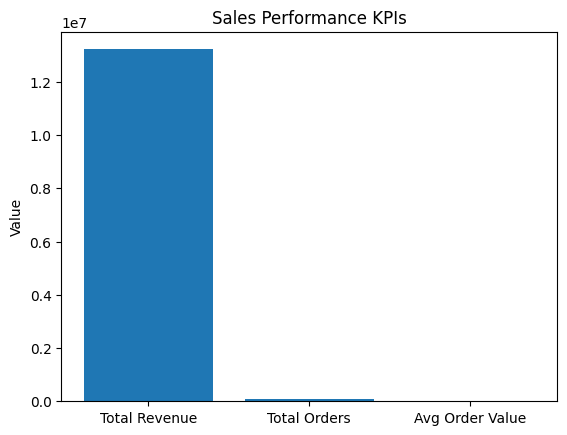

In [ ]:
import matplotlib.pyplot as plt

kpi_labels = ["Total Revenue", "Total Orders", "Avg Order Value"]
kpi_values = [
    total_revenue,
    total_orders,
    avg_order_value
]

plt.figure()
plt.bar(kpi_labels, kpi_values)
plt.title("Sales Performance KPIs")
plt.ylabel("Value")
plt.show()


#### **7.2 Monthly Revenue Trend**

What this shows :
1.   Seasonality
2.   Growth/decline patterns
3.   Business cycles


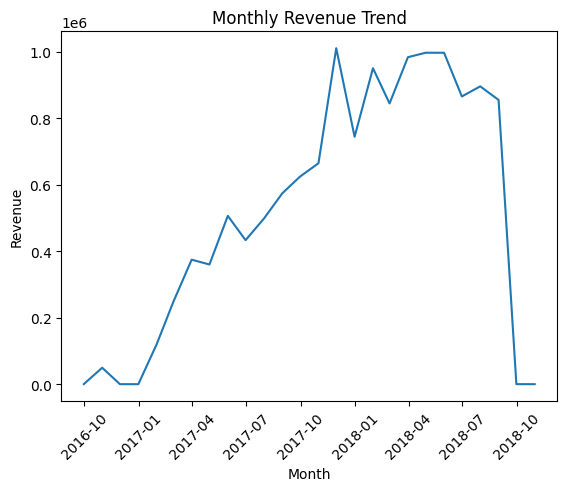

In [ ]:
plt.figure()
plt.plot(
    monthly_sales["order_purchase_timestamp"],
    monthly_sales["total_price"]
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


### **DASHBOARD 2 — CUSTOMER SENTIMENT DASHBOARD**
#### **7.3 Sentiment Distribution**



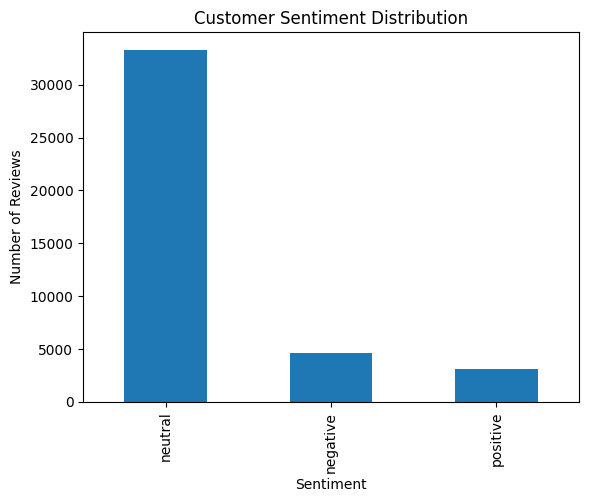

In [ ]:
sentiment_counts = reviews["sentiment"].value_counts()

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


Business insight:
1.   Customer satisfaction level
2.   Volume of negative feedback



#### **7.4 Sentiment vs Revenue Impact**


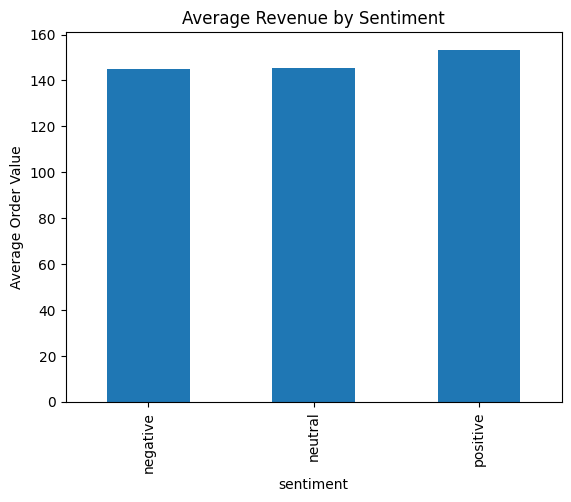

In [ ]:
sentiment_revenue = (
    sentiment_sales
    .groupby("sentiment")["total_price"]
    .mean()
)

plt.figure()
sentiment_revenue.plot(kind="bar")
plt.title("Average Revenue by Sentiment")
plt.ylabel("Average Order Value")
plt.show()


1.   Shows correlation between customer sentiment and spending
2.   Supports data-driven customer experience strategies

### **DASHBOARD 3 — SALES FORECASTING DASHBOARD**
##### **7.5 Prophet Forecast Visualization**

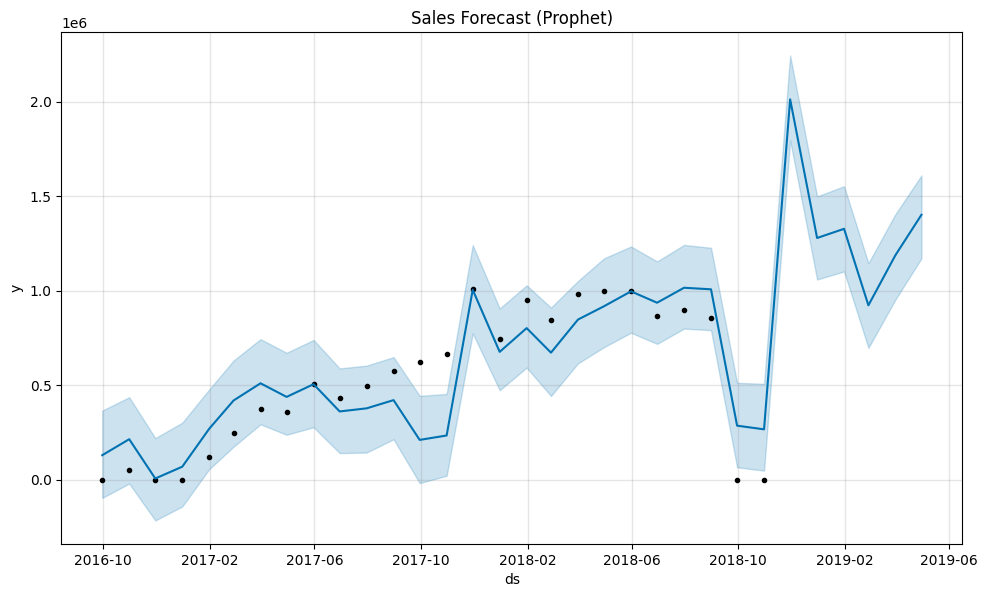

In [ ]:
prophet_model.plot(forecast)
plt.title("Sales Forecast (Prophet)")
plt.show()


#### **7.6 Prophet vs ARIMA**

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Prophet", "ARIMA"],
    "MAE": [mae_prophet, mae_arima],
    "RMSE": [rmse_prophet, rmse_arima]
})

model_comparison


,Model,MAE,RMSE
0,Prophet,149179.05763,180216.051887
1,ARIMA,415747.70893,595957.639805


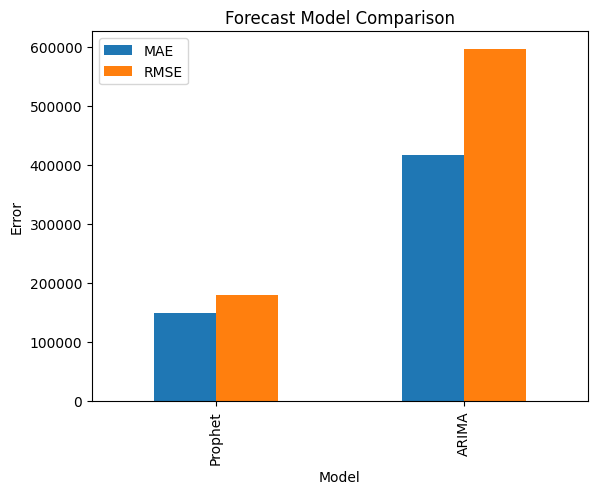

In [ ]:
model_comparison.set_index("Model").plot(kind="bar")
plt.title("Forecast Model Comparison")
plt.ylabel("Error")
plt.show()
